<a href="https://colab.research.google.com/github/Davidayo123/Multimodal-Sentiment-Analysis/blob/main/Multimodal_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import pandas as pd

print("🚀 Initializing Project 3 Workspace...\n")

# 1. Securely connect to actual Google Drive
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted and accessible!")

# 2. Define and create the exact folder path
# Making sure it goes straight into your Data Science Projects folder
project_dir = '/content/drive/MyDrive/my projects/data science projects/Multimodal_Sentiment_Analysis'
os.makedirs(project_dir, exist_ok=True)

# 3. Change working directory so files save here
os.chdir(project_dir)
print(f"Current Working Directory: {os.getcwd()}\n")

# 4. Generate the Unstructured Social Media Data
print("Generating messy social media dataset (with emojis and internet slang)...")

data = {
    'post_id': range(1, 11),
    'platform': ['Twitter', 'Reddit', 'Twitter', 'TrustPilot', 'Twitter', 'Reddit', 'Twitter', 'TrustPilot', 'Reddit', 'Twitter'],
    'raw_text': [
        "The new UI update is absolutely terrible 🤮 I can't find anything anymore.",
        "Just finished watching the season finale. It was okay, nothing special.",
        "OMG the stream quality is amazing today! 🔥🔥🔥 Best service ever.",
        "Customer support hung up on me. Completely unacceptable.",
        "Loving the new documentary series! 🍿 Highly recommend.",
        "Buffering... buffering... buffering... fix your servers! 😡",
        "It's decent for the price, but the catalog is shrinking.",
        "I was charged twice this month. Need a refund ASAP 💸",
        "Honestly, the recommendation algorithm is getting so good. Spot on.",
        "Meh. It works when it wants to. 🤷‍♂️"
    ]
}

df = pd.DataFrame(data)

# 5. Save the raw dataset to your Drive
df.to_csv("brand_mentions_raw.csv", index=False)
print("✅ Dataset generated and safely saved as 'brand_mentions_raw.csv'\n")

# Display the raw data we have to process
print("--- Raw Unstructured Data ---")
display(df[['platform', 'raw_text']])

🚀 Initializing Project 3 Workspace...

Mounting Google Drive...
Mounted at /content/drive
Current Working Directory: /content/drive/MyDrive/my projects/data science projects/Multimodal_Sentiment_Analysis

Generating messy social media dataset (with emojis and internet slang)...
✅ Dataset generated and safely saved as 'brand_mentions_raw.csv'

--- Raw Unstructured Data ---


,platform,raw_text
0,Twitter,The new UI update is absolutely terrible 🤮 I c...
1,Reddit,Just finished watching the season finale. It w...
2,Twitter,OMG the stream quality is amazing today! 🔥🔥🔥 B...
3,TrustPilot,Customer support hung up on me. Completely una...
4,Twitter,Loving the new documentary series! 🍿 Highly re...
5,Reddit,Buffering... buffering... buffering... fix you...
6,Twitter,"It's decent for the price, but the catalog is ..."
7,TrustPilot,I was charged twice this month. Need a refund ...
8,Reddit,"Honestly, the recommendation algorithm is gett..."
9,Twitter,Meh. It works when it wants to. 🤷‍♂️


In [2]:
# 1. Install the Hugging Face datasets library
!pip install datasets

import pandas as pd
from datasets import load_dataset
import os

print("🚀 Connecting to Hugging Face Data Hub...")

# 2. Programmatically download the real Twitter sentiment dataset (approx 45,000+ real tweets)
# We will pull the 'train' split which has the most data
dataset = load_dataset("tweet_eval", "sentiment")
real_tweets = dataset['train']

# 3. Convert the Hugging Face dataset into a Pandas DataFrame
df = pd.DataFrame(real_tweets)

# 4. Clean up the columns to make it readable
# TweetEval uses 0: Negative, 1: Neutral, 2: Positive
label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['actual_sentiment'] = df['label'].map(label_mapping)
df = df.rename(columns={'text': 'raw_text'})
df = df[['raw_text', 'actual_sentiment']] # Keep only what we need

# 5. Save this massive, real dataset to your Google Drive
df.to_csv("brand_mentions_raw.csv", index=False)
print(f"✅ Successfully ingested {len(df)} real tweets!")
print("Dataset safely saved to Google Drive as 'brand_mentions_raw.csv'\n")

# 6. Display a random sample of the chaos we are about to analyze
print("--- Random Sample of Real Unstructured Data ---")
display(df.sample(10))

🚀 Connecting to Hugging Face Data Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Successfully ingested 45615 real tweets!
Dataset safely saved to Google Drive as 'brand_mentions_raw.csv'

--- Random Sample of Real Unstructured Data ---


,raw_text,actual_sentiment
33329,Just little old me in the paper today! Here's ...,Positive
6791,What to expect besides the new iPhone 6S at Ap...,Neutral
29599,@user So what If the rules were spelled out ba...,Neutral
21840,In the Sports World Report: Steelers can\u2019...,Negative
10655,@user and you will be procrastinating to see S...,Neutral
29483,"""// -- cinema this Saturday. I would love to s...",Neutral
23739,Here is the average NFL rank of Peyton Manning...,Neutral
4343,"""These ratings speak more to Naruto than One P...",Positive
7665,i am going to try to meet Michelle Obama on fr...,Positive
22269,Work till friday..then new york for the weeken...,Neutral


In [3]:
# 1. Install required deep learning libraries
!pip install transformers torch scipy

import pandas as pd
from transformers import pipeline
import torch

print("Loading the RoBERTa Deep Learning Model from Hugging Face...")

# 2. Check for GPU acceleration (Colab Free tier usually offers T4 GPUs)
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("✅ GPU detected! Inference will be blazingly fast.")
else:
    print("⚠️ No GPU detected. Running on CPU (This will be slower).")

# 3. Initialize the Sentiment Pipeline
# Using CardiffNLP's Twitter RoBERTa model, the industry standard for social media text
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    max_length=512,
    truncation=True,
    device=device
)

print("Model loaded! Sampling data and running inference...\n")

# 4. Load our massive dataset and take a 1,000-row sample for the portfolio
df = pd.read_csv("brand_mentions_raw.csv")
df_sample = df.sample(n=1000, random_state=42).copy()

# 5. Run the text through the deep learning model
# We extract the text column to a list for the pipeline
tweets_to_analyze = df_sample['raw_text'].tolist()
results = sentiment_analyzer(tweets_to_analyze)

# 6. Extract the labels and confidence scores
df_sample['ai_sentiment'] = [result['label'].capitalize() for result in results]
df_sample['confidence_score'] = [round(result['score'], 4) for result in results]

# 7. Save the processed sample to your Drive
df_sample.to_csv("analyzed_tweets_sample.csv", index=False)

print("✅ Sentiment Analysis Complete! All artifacts saved.")
print("\n--- AI Model Predictions vs Actual ---")
display(df_sample[['raw_text', 'actual_sentiment', 'ai_sentiment', 'confidence_score']].head(10))

Loading the RoBERTa Deep Learning Model from Hugging Face...
✅ GPU detected! Inference will be blazingly fast.


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded! Sampling data and running inference...

✅ Sentiment Analysis Complete! All artifacts saved.

--- AI Model Predictions vs Actual ---


,raw_text,actual_sentiment,ai_sentiment,confidence_score
11449,I forgot all about Ice Cube being in the movie...,Negative,Negative,0.6545
26433,playoffs are finally set. Chardon plays warren...,Neutral,Neutral,0.8531
33669,Are we just going to ignore the fact that Ice ...,Neutral,Negative,0.4981
33013,If you live in the South Orlando area\u002c be...,Neutral,Neutral,0.7650
13399,First record of Colin Baker at the BBC: BBC2 s...,Neutral,Neutral,0.7533
16963,Tomorrow night I'll be at Citi Field with the ...,Positive,Positive,0.6160
2868,"""Frank Gifford died Sunday AM in his CT home. ...",Positive,Positive,0.8694
12710,People talkin shit just wait I\u2019ll be in H...,Negative,Neutral,0.4627
8161,Intrigued by the mentions of alternate realiti...,Neutral,Neutral,0.5379
1841,"""Gandhi:There may be violence, but then again ...",Neutral,Neutral,0.7530


Evaluating RoBERTa Model Performance...

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.69      0.82      0.75       158
     Neutral       0.75      0.74      0.74       427
    Positive       0.84      0.79      0.82       415

    accuracy                           0.77      1000
   macro avg       0.76      0.78      0.77      1000
weighted avg       0.78      0.77      0.77      1000


✅ Evaluation complete! All metrics and plots saved to Google Drive.


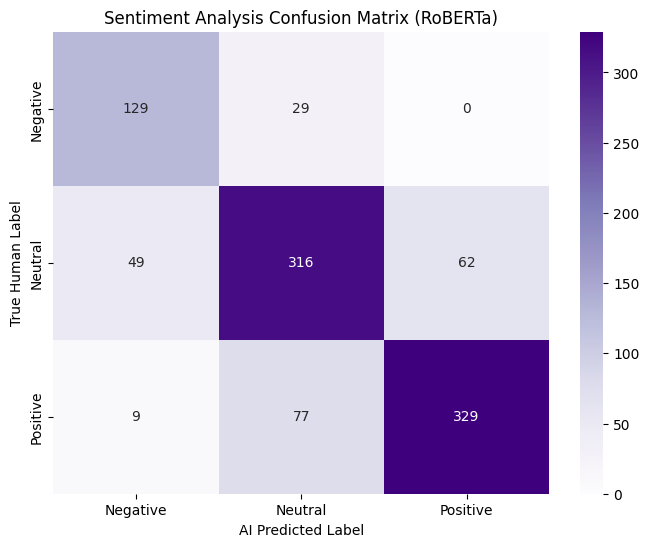

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating RoBERTa Model Performance...\n")

# 1. Clean data just in case of casing mismatches
df_sample['actual_sentiment'] = df_sample['actual_sentiment'].str.capitalize()
df_sample['ai_sentiment'] = df_sample['ai_sentiment'].str.capitalize()

# 2. Generate and print the classification report
report_text = classification_report(df_sample['actual_sentiment'], df_sample['ai_sentiment'])
print("--- Classification Report ---")
print(report_text)

# --- PROFESSIONAL UPDATE: Save the Report ---
with open("sentiment_classification_report.txt", "w") as f:
    f.write("RoBERTa Sentiment Analysis Report\n=================================\n\n")
    f.write(report_text)

# 3. Build the Multi-class Confusion Matrix
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(df_sample['actual_sentiment'], df_sample['ai_sentiment'], labels=labels)

# Save raw matrix data
pd.DataFrame(cm, index=[f'Actual {l}' for l in labels], columns=[f'Predicted {l}' for l in labels]).to_csv("sentiment_matrix_data.csv")

# 4. Plot the Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Sentiment Analysis Confusion Matrix (RoBERTa)')
plt.ylabel('True Human Label')
plt.xlabel('AI Predicted Label')

# --- PROFESSIONAL UPDATE: Save the Plot ---
plt.savefig("sentiment_confusion_matrix.png", dpi=300, bbox_inches='tight')
print("\n✅ Evaluation complete! All metrics and plots saved to Google Drive.")

# Display the plot
plt.show()

Generating Executive Brand Health Dashboard...

✅ Executive Dashboard plot saved as 'brand_sentiment_distribution.png'



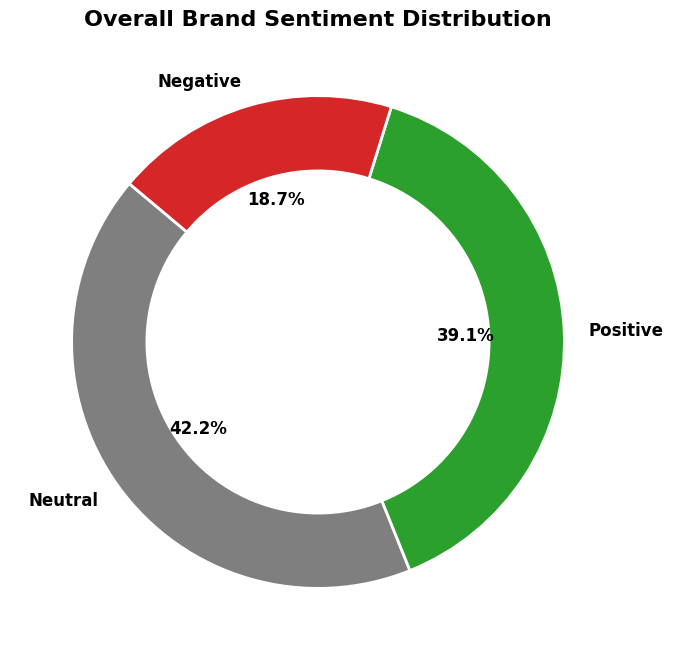

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Executive Brand Health Dashboard...\n")

# 1. Count the AI's predictions
sentiment_counts = df_sample['ai_sentiment'].value_counts()

# 2. Set up the Donut Chart with professional styling
plt.figure(figsize=(8, 8))

# Dynamically map colors so Positive is always Green, Negative is Red, Neutral is Gray
color_map = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}
pie_colors = [color_map.get(label, '#333333') for label in sentiment_counts.index]

# Create the base pie chart
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=pie_colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# Draw a white circle in the center to turn it into a modern donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Brand Sentiment Distribution', fontsize=16, fontweight='bold')

# 3. SAVE the plot (must be before plt.show)
plt.savefig("brand_sentiment_distribution.png", dpi=300, bbox_inches='tight')
print("✅ Executive Dashboard plot saved as 'brand_sentiment_distribution.png'\n")

# Display the plot
plt.show()